torch.Size([2, 1, 64])


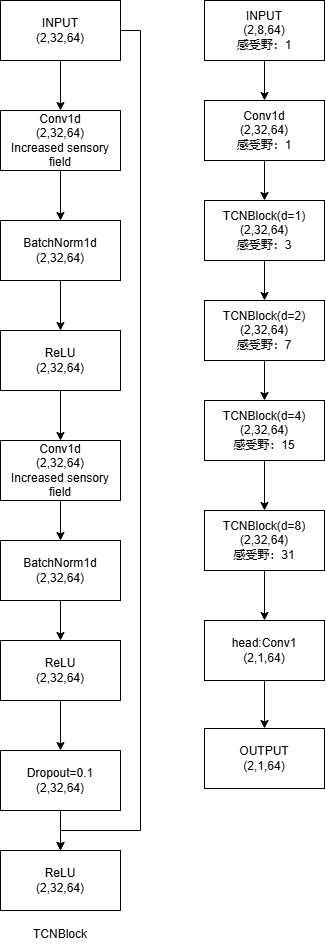

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
class TCN(nn.Module):
    class TCNBlock(nn.Module):
        def __init__(self,ch,dilation,kernel=3,dropout=0.1):
            super().__init__()
            pad = (kernel-1) * dilation
            self.conv1 = nn.Conv1d(ch,ch,kernel,padding=pad,dilation=dilation)
            self.conv2 = nn.Conv1d(ch,ch,kernel,padding=pad,dilation=dilation)
            self.bn1 = nn.BatchNorm1d(ch)
            self.bn2 = nn.BatchNorm1d(ch)
            self.drop = nn.Dropout(dropout)
            self.pad = pad
        def forward(self,x):
            res = x
            h = F.relu(self.bn1(self.conv1(x)[...,:-self.pad] if self.pad else self.conv1(x)))
            h = self.drop(F.relu(self.bn2(self.conv2(h)[...,:-self.pad] if self.pad else self.conv2(h))))
            return F.relu(h+res)
    def __init__(self,in_ch=8,ch=32,levels=4):
        super().__init__()
        self.proj = nn.Conv1d(in_ch,ch,1)
        self.blocks = nn.ModuleList(
            [self.TCNBlock(ch,dilation=2 **i) for i in range(levels)]
        )
        self.head = nn.Conv1d(ch,1,1)
    def forward(self,x):
        x = self.proj(x)
        for b in self.blocks:
            x = b(x)
        return self.head(x)

model = TCN()
model.eval()
with torch.no_grad():
    out = model(torch.randn(2,8,64))
    print(out.shape)
from PIL import Image
import IPython.display as display
img = Image.open('tcn.png')
display.display(img) 